In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import scipy
from tqdm import tqdm
import collections
%matplotlib inline

### Import Files

In [2]:
#Background Files
bkgd1 = uproot.open('data/user.ebusch.364702.root')
bkgd2 = uproot.open('data/user.ebusch.364703.root')
bkgd3 = uproot.open('data/user.ebusch.364704.root')
bkgd4 = uproot.open('data/user.ebusch.364705.root')
bkgd5 = uproot.open('data/user.ebusch.364706.root')
bkgd6 = uproot.open('data/user.ebusch.364707.root')
bkgd7 = uproot.open('data/user.ebusch.364708.root')
bkgd8 = uproot.open('data/user.ebusch.364709.root')
bkgd9 = uproot.open('data/user.ebusch.364710.root')
bkgd10 = uproot.open('data/user.ebusch.364711.root')
bkgd11 = uproot.open('data/user.ebusch.364712.root')

#Signal Files
sig1 = uproot.open('data/user.ebusch.508547.root')
sig2 = uproot.open('data/user.ebusch.508548.root')
sig3 = uproot.open('data/user.ebusch.508549.root')
sig4 = uproot.open('data/user.ebusch.508550.root')

### Prepare data

In [3]:
# "bkgd1", "bkgd2", "bkgd3", "bkgd4", "bkgd5", "bkgd6", "bkgd7", "bkgd8", "bkgd9", "bkgd10", "bkgd11"
# "sig1", "sig2", "sig3", "sig4"
bfiles = ["bkgd4", "bkgd5", "bkgd6", "bkgd7", "bkgd8", "bkgd9", "bkgd10", "bkgd11", "sig1", "sig2", "sig3", "sig4"]
features = ['jet1_Split12', 'jet1_Split23', 'jet1_D2', 'jet1_C2', 'jet1_tau32','jet2_pt', 'jet2_Split12', 'jet2_Split23', 'jet2_D2', 'jet2_C2', 'jet2_tau32']
df = pd.DataFrame()

#0 --> background
#1 --> signal

for filename in tqdm(bfiles):
    tmp = (globals()[filename])['PostSel'].arrays(features, library="pd")
    lb_tmp = 0 if "bkgd" in filename else 1
    tmp['label'] = np.full(len(tmp[features[0]]), lb_tmp)
    df = pd.concat([df, tmp], axis=0)


X = df.loc[:, features]
y = df.label

100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [01:07<00:00,  5.65s/it]


In [4]:
df.head()

,jet1_Split12,jet1_Split23,jet1_D2,jet1_C2,jet1_tau32,jet2_pt,jet2_Split12,jet2_Split23,jet2_D2,jet2_C2,jet2_tau32,label
0,13.803514,8.701515,3.241316,0.071092,0.316464,874.435425,29.174429,15.217295,2.142663,0.120263,0.709514,0
1,56.282658,17.833273,1.988891,0.156934,0.790626,689.197571,17.807692,5.583016,2.449438,0.069558,0.740852,0
2,145.213943,53.825859,1.144231,0.143903,0.602986,933.875488,19.071886,13.365583,2.337232,0.072563,0.574568,0
3,8.216363,4.445688,3.906110,0.038565,0.150783,1197.661133,27.359461,8.457346,2.596627,0.085776,0.637132,0
4,15.251266,9.580124,3.671137,0.085534,0.479478,1020.577087,38.866463,16.692808,3.377606,0.236285,0.740736,0


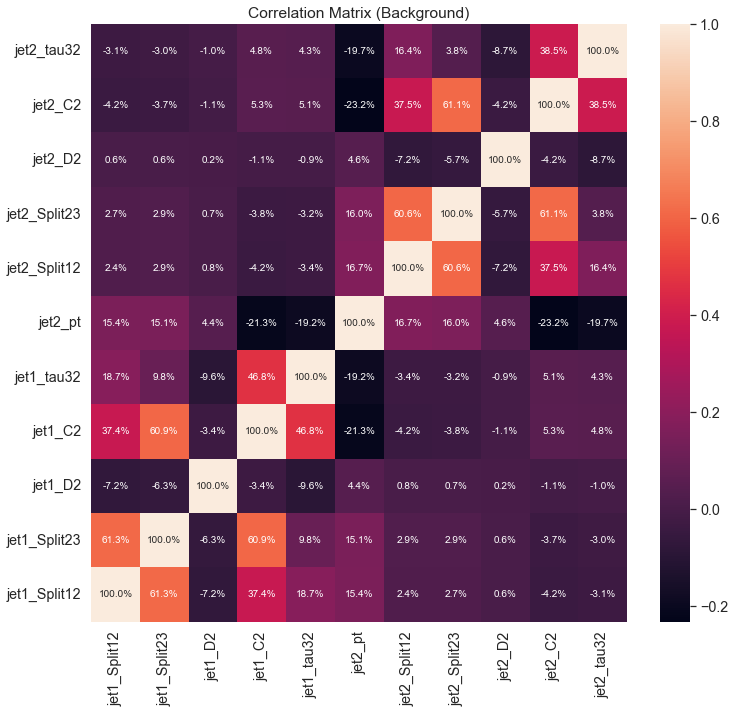

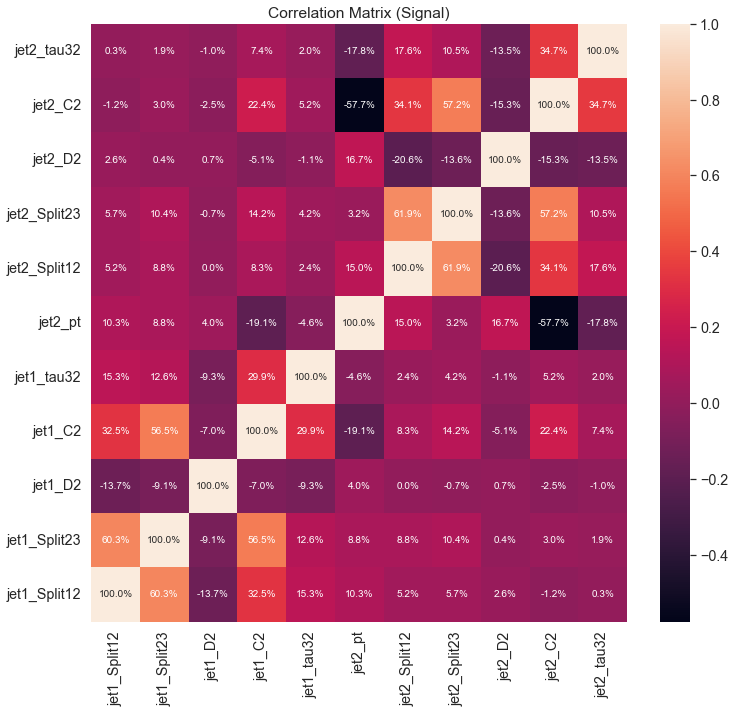

In [43]:
#Plot Correlation Matrix

import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

df_b = df.loc[df['label'] == 0].drop('label', axis=1)
df_s = df.loc[df['label'] == 1].drop('label', axis=1)

cm_b = df_b.corr()
cm_s = df_s.corr()

plt.figure(figsize = (12,11))
ax = plt.axes()
sn.heatmap(cm_b, annot=True, fmt=".1%", ax = ax).invert_yaxis()
ax.set_title('Correlation Matrix (Background)')
plt.show()

plt.figure(figsize = (12,11))
ax = plt.axes()
sn.heatmap(cm_s, annot=True, fmt=".1%", ax = ax).invert_yaxis()
ax.set_title('Correlation Matrix (Signal)')
plt.show()

### Train Model

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(np.nan_to_num(X), y, test_size=0.30)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(verbose=1)
#clf = DecisionTreeClassifier(max_depth=3)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

      Iter       Train Loss   Remaining Time 
         1           0.0168          242.49m
         2           0.0154          240.83m
         3           0.0142          237.81m
         4           0.0131          234.98m
         5           0.0122          234.13m
         6           0.0113          233.85m
         7           0.0105          236.88m
         8           0.0097          240.40m
         9           0.0091          242.28m
        10           0.0085          246.13m


### Visualize

In [46]:
#Visualize Decision Tree
'''
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(200,100))
a = tree.plot_tree(clf, feature_names = features, class_names = ["background", "signal"], rounded = True, filled = True, fontsize=14)
plt.show()
'''

'\nfrom sklearn import tree\nimport matplotlib.pyplot as plt\nplt.figure(figsize=(200,100))\na = tree.plot_tree(clf, feature_names = features, class_names = ["background", "signal"], rounded = True, filled = True, fontsize=14)\nplt.show()\n'

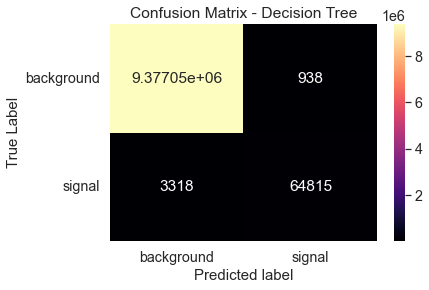

<Figure size 720x504 with 0 Axes>

In [47]:
#Plot Confusion Matrix

from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

matrix_df = pd.DataFrame(confusion_matrix)
ax = plt.axes()
sns.set(font_scale=1.3)
plt.figure(figsize=(10,7))
sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="magma")

ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel("Predicted label", fontsize =15)
ax.set_xticklabels(["background", "signal"])
ax.set_ylabel("True Label", fontsize=15)
ax.set_yticklabels(list(["background", "signal"]), rotation = 0)
plt.show()

In [48]:
#Analyze accuracy and importance

from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

#extract importance
importance = pd.DataFrame({'feature': features, 
'importance' : np.round(clf.feature_importances_, 3)})
importance.sort_values('importance', ascending=False, inplace = True)
print(importance)

Accuracy: 0.9995494444966116
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   9377984
           1       0.99      0.95      0.97     68133

    accuracy                           1.00   9446117
   macro avg       0.99      0.98      0.98   9446117
weighted avg       1.00      1.00      1.00   9446117

         feature  importance
5        jet2_pt       0.998
2        jet1_D2       0.002
0   jet1_Split12       0.000
1   jet1_Split23       0.000
3        jet1_C2       0.000
4     jet1_tau32       0.000
6   jet2_Split12       0.000
7   jet2_Split23       0.000
8        jet2_D2       0.000
9        jet2_C2       0.000
10    jet2_tau32       0.000


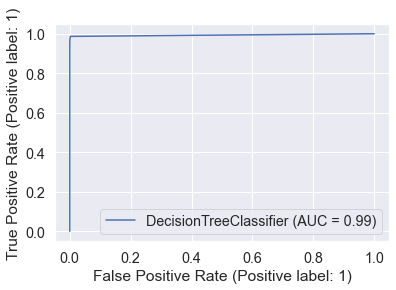

In [49]:
metrics.plot_roc_curve(clf, X_test, y_test) 
plt.show()

In [50]:
clf.score(X_train, y_train)

0.9995465256720687